In [1]:
%load_ext autoreload
%autoreload 2

In [7]:
import sys
from pathlib import Path
import os

PROJECT_ROOT = Path.cwd().parent
print("PROJECT ROOT ==>", PROJECT_ROOT)

sys.path.append(str(PROJECT_ROOT))

from src.landmark_eval import evaluate_all_scans, evaluate_dataset, load_gt, load_pred
from src.pred_gt_viewer_viz import visualize_pred_and_gt,load_pred_landmarks
from src.mesh_fun import (
    load_mesh, load_landmarks, create_landmark_spheres, visualize,color_mesh_by_groups,load_segmentation
)
from src.utils_fun import compute_quantile_table,plot_quantile
from src.var_constants import CATEGORIES,TOOTH_TO_GROUP,TOOTH_GROUP_PALETTE,LANDMARK_PALETTE
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import open3d as o3d



PROJECT ROOT ==> C:\Users\aless\Tesi_Msc\multi_agent_evaluation_on_intraoral_3D_scans


In [3]:
DATA_ROOT = PROJECT_ROOT / "dataset"
SCANS = DATA_ROOT / "toothinstancenet_input"
GT_ROOT = SCANS
PRED_CSV = DATA_ROOT / "model_predictions" / "ynlab" / "predictions.csv"

print("SCANS:", SCANS)
print("GT_ROOT:", GT_ROOT)
print("PRED_CSV:", PRED_CSV)


SCANS: c:\Users\aless\Tesi_Msc\multi_agent_evaluation_on_intraoral_3D_scans\dataset\toothinstancenet_input
GT_ROOT: c:\Users\aless\Tesi_Msc\multi_agent_evaluation_on_intraoral_3D_scans\dataset\toothinstancenet_input
PRED_CSV: c:\Users\aless\Tesi_Msc\multi_agent_evaluation_on_intraoral_3D_scans\dataset\model_predictions\ynlab\predictions.csv


In [4]:
###check obj
objs = sorted(list(SCANS.glob("*.obj")))
print("Numero totale di OBJ:", len(objs))

Numero totale di OBJ: 66


#### calcola mAP, mARP globale e per categoria

In [7]:
results_global, mAP_global, mAR_global = evaluate_dataset(GT_ROOT, PRED_CSV, categories=CATEGORIES)

print("=== RISULTATI GLOBALI (ufficiali) ===")
for cat, vals in results_global.items():
    print(f"{cat}: AP={vals['AP']:.4f}, AR={vals['AR']:.4f}")

print("\nMETRICHE TOTALI:")
print(f"mAP = {mAP_global:.4f}")
print(f"mAR = {mAR_global:.4f}")


=== RISULTATI GLOBALI (ufficiali) ===
Mesial: AP=0.6017, AR=0.4783
Distal: AP=0.5437, AR=0.4456
Cusp: AP=0.6098, AR=0.4455
InnerPoint: AP=0.5919, AR=0.4564
OuterPoint: AP=0.6140, AR=0.4829
FacialPoint: AP=0.5922, AR=0.5423

METRICHE TOTALI:
mAP = 0.5922
mAR = 0.4752


#### calcola mAP, mARP per scan e per categoria

***results*** dict_keys(['scans', 'ap_per_scan', 'ar_per_scan', 'gt_count_per_scan', 'mAP_per_scan', 'mAR_per_scan'])


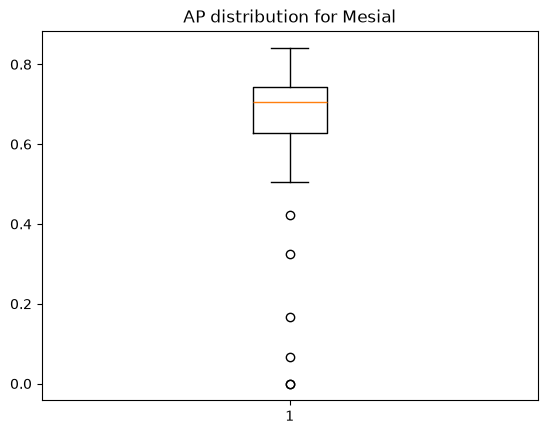

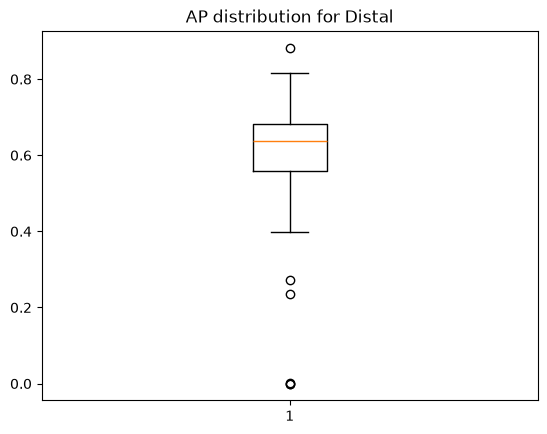

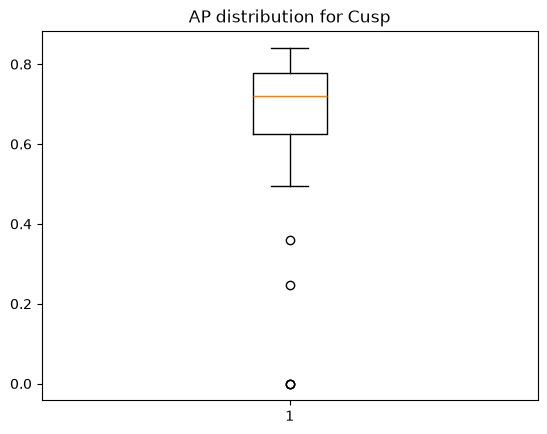

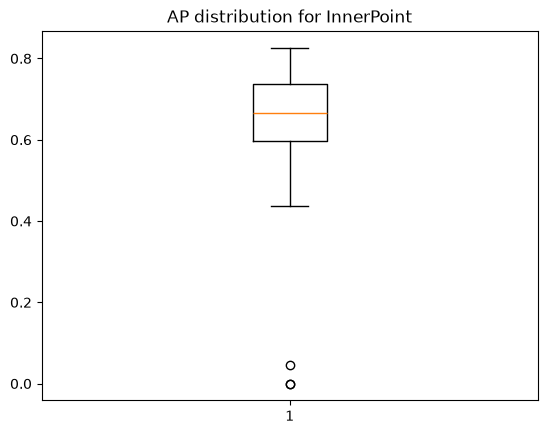

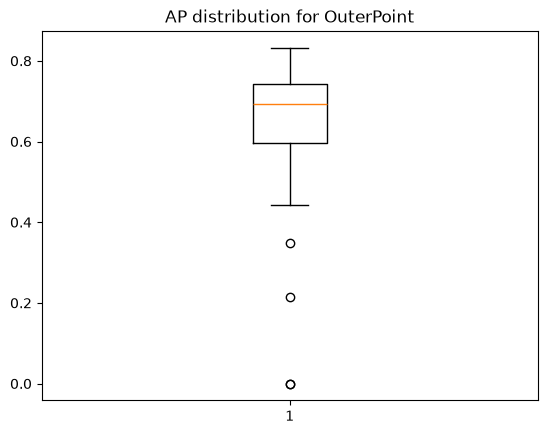

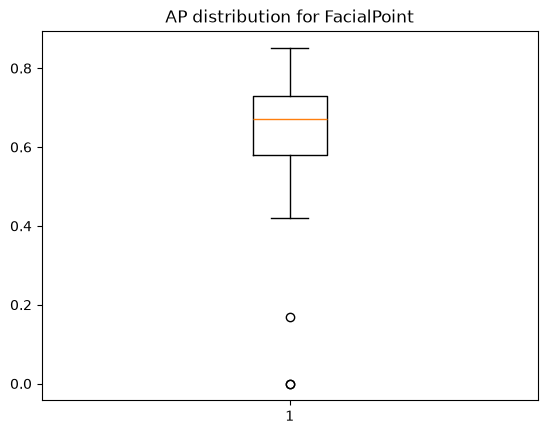

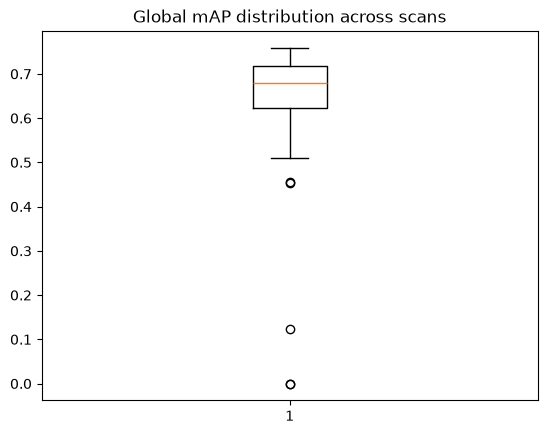

In [8]:
results = evaluate_all_scans(GT_ROOT, PRED_CSV, categories=CATEGORIES)
print('***results***', results.keys())
#Boxplot per categoria (AP)
for cat in CATEGORIES:
    plt.figure()
    plt.boxplot(results["ap_per_scan"][cat])
    plt.title(f"AP distribution for {cat}")
    plt.show()

#Boxplot globale (mAP) (mediamo rispetto a ogni scan (ap x categoria) e poi facciamo la media per scan)
plt.figure()
plt.boxplot(results["mAP_per_scan"])
plt.title("Global mAP distribution across scans")
plt.show()


#### distribuzione map, mar via quantili

In [9]:
quantile_mAP = compute_quantile_table(results["mAP_per_scan"], quantiles=list(np.arange(0,1,0.05)))
quantile_mAR = compute_quantile_table(results["mAR_per_scan"])

print("\n=== Quantile table global mAP per scan ===")
print(quantile_mAP)

print("\n=== Quantile table global mAR per scan ===")
print(quantile_mAR)



=== Quantile table global mAP per scan ===
    quantile     value
0       0.00  0.000000
1       0.05  0.454018
2       0.10  0.550665
3       0.15  0.575901
4       0.20  0.599011
5       0.25  0.623364
6       0.30  0.636655
7       0.35  0.650346
8       0.40  0.662711
9       0.45  0.671457
10      0.50  0.679340
11      0.55  0.686030
12      0.60  0.697359
13      0.65  0.703670
14      0.70  0.706330
15      0.75  0.718218
16      0.80  0.723566
17      0.85  0.735992
18      0.90  0.744729
19      0.95  0.755517

=== Quantile table global mAR per scan ===
   quantile     value
0      0.10  0.409031
1      0.25  0.444902
2      0.50  0.489016
3      0.75  0.532614
4      0.90  0.563665


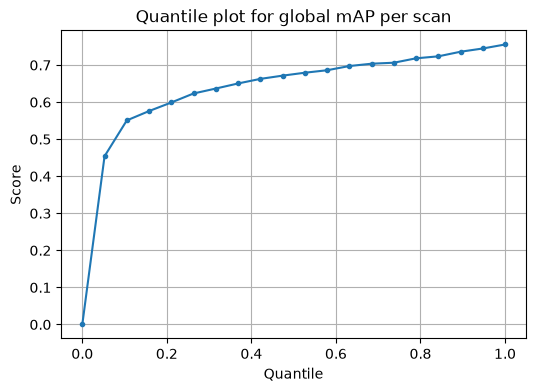

In [14]:
plot_quantile(quantile_mAP.value, title="Quantile plot for global mAP per scan")

In [27]:
#### come sopra, ma per categoria (AP e AR)
quantile_tables_ap = {}
quantile_tables_ar = {}

for cat in CATEGORIES:
    vals_ap = results["ap_per_scan"][cat]
    vals_ar = results["ar_per_scan"][cat]

    if len(vals_ap) > 0:
        quantile_tables_ap[cat] = compute_quantile_table(vals_ap)

    if len(vals_ar) > 0:
        quantile_tables_ar[cat] = compute_quantile_table(vals_ar)
for cat in CATEGORIES:
    print(f"\n=== Quantile table AP => {cat} ===")
    print(quantile_tables_ap[cat])

    print(f"\n=== Quantile table AR => {cat} ===")
    print(quantile_tables_ar[cat])



=== Quantile table AP => Mesial ===
   quantile     value
0      0.10  0.513137
1      0.25  0.627812
2      0.50  0.705993
3      0.75  0.743628
4      0.90  0.787245

=== Quantile table AR => Mesial ===
   quantile     value
0      0.10  0.421281
1      0.25  0.487396
2      0.50  0.550961
3      0.75  0.596837
4      0.90  0.640472

=== Quantile table AP => Distal ===
   quantile     value
0      0.10  0.488097
1      0.25  0.559520
2      0.50  0.636687
3      0.75  0.683302
4      0.90  0.752603

=== Quantile table AR => Distal ===
   quantile     value
0      0.10  0.363577
1      0.25  0.452473
2      0.50  0.511161
3      0.75  0.548481
4      0.90  0.584556

=== Quantile table AP => Cusp ===
   quantile     value
0      0.10  0.500553
1      0.25  0.630626
2      0.50  0.721141
3      0.75  0.779027
4      0.90  0.822575

=== Quantile table AR => Cusp ===
   quantile     value
0      0.10  0.425514
1      0.25  0.488051
2      0.50  0.585249
3      0.75  0.663982
4      0.90 

### Top & worst k scan per categoria e globalmente. Da valutare visiviamente successivamente 

In [97]:
results.keys()

dict_keys(['scans', 'ap_per_scan', 'ar_per_scan', 'mAP_per_scan', 'mAR_per_scan'])

In [112]:
def top_k_scans_per_category(results, categories, k=5):
    top_ap = {}
    top_ar = {}

    for cat in categories:
        values_ap = results["ap_per_scan"][cat]
        values_ar = results["ar_per_scan"][cat]
        scans = results["scans"]

        ap_pairs = list(zip(scans, values_ap))
        ar_pairs = list(zip(scans, values_ar))

        ap_sorted = sorted(ap_pairs, key=lambda x: x[1], reverse=True)
        ar_sorted = sorted(ar_pairs, key=lambda x: x[1], reverse=True)

        top_ap[cat] = ap_sorted[:k]
        top_ar[cat] = ar_sorted[:k]

    return top_ap, top_ar

def worst_k_scans_per_category(results, categories, k=5):
    worst_ap = {}
    worst_ar = {}

    for cat in categories:
        values_ap = results["ap_per_scan"][cat]
        values_ar = results["ar_per_scan"][cat]
        scans = results["scans"]

        ap_pairs = list(zip(scans, values_ap))
        ar_pairs = list(zip(scans, values_ar))

        ap_sorted = sorted(ap_pairs, key=lambda x: x[1])
        ar_sorted = sorted(ar_pairs, key=lambda x: x[1])

        worst_ap[cat] = ap_sorted[:k]
        worst_ar[cat] = ar_sorted[:k]

    return worst_ap, worst_ar

def top_k_global(results, k=5):
    scans = results["scans"]
    mAP = results["mAP_per_scan"]
    mAR = results["mAR_per_scan"]

    ap_pairs = list(zip(scans, mAP))
    ar_pairs = list(zip(scans, mAR))

    ap_sorted = sorted(ap_pairs, key=lambda x: x[1], reverse=True)
    ar_sorted = sorted(ar_pairs, key=lambda x: x[1], reverse=True)

    return ap_sorted[:k], ar_sorted[:k]


def worst_k_global(results, k=5):
    scans = results["scans"]
    mAP = results["mAP_per_scan"]
    mAR = results["mAR_per_scan"]

    ap_pairs = list(zip(scans, mAP))
    ar_pairs = list(zip(scans, mAR))

    ap_sorted = sorted(ap_pairs, key=lambda x: x[1])
    ar_sorted = sorted(ar_pairs, key=lambda x: x[1])

    return ap_sorted[:k], ar_sorted[:k]


top_ap_cat, top_ar_cat = top_k_scans_per_category(results, CATEGORIES, k=2)
worst_ap_cat, worst_ar_cat = worst_k_scans_per_category(results, CATEGORIES, k=2)

top_global_ap, top_global_ar = top_k_global(results, k=10)
worst_global_ap, worst_global_ar = worst_k_global(results, k=20)


In [113]:
top_global_ap

[('AKBDPB4C_upper', np.float64(0.7594368136373006)),
 ('J1A5FRQN_upper', np.float64(0.7578058918176606)),
 ('X273URFW_lower', np.float64(0.7571695607488212)),
 ('XNNZTXK5_lower', np.float64(0.756734339293863)),
 ('CK45DVLG_upper', np.float64(0.7518633768429344)),
 ('HDVYC7UQ_upper', np.float64(0.7491915478609427)),
 ('RZ69JRI9_lower', np.float64(0.7461829135494465)),
 ('ZGH1UT1Q_lower', np.float64(0.7432758427001849)),
 ('X9OQZ131_lower', np.float64(0.7422083689262983)),
 ('XKTTBEE0_lower', np.float64(0.736237401813176))]

In [114]:
worst_global_ap

[('ANLLPLV7_upper', np.float64(0.0)),
 ('YNKZHRP0_lower', np.float64(0.0)),
 ('K70NYZYE_upper', np.float64(0.12399414114691891)),
 ('RUXSXSCL_lower', np.float64(0.4537507220053709)),
 ('S0AON6PZ_lower', np.float64(0.45481922398589064)),
 ('QPYE7NOP_lower', np.float64(0.5094730069322624)),
 ('PYKS3V33_lower', np.float64(0.5406555248039641)),
 ('JXVWXY0L_upper', np.float64(0.5606752956405734)),
 ('H5EFRXCQ_upper', np.float64(0.5641242060862158)),
 ('PY6M5YZ2_lower', np.float64(0.5665287286607288)),
 ('Y8BV16EI_lower', np.float64(0.5790255583935716)),
 ('VCVHV931_lower', np.float64(0.5902743584200385)),
 ('CLNVA9MZ_upper', np.float64(0.5933019461176811)),
 ('QA27COSZ_lower', np.float64(0.5990114177222572)),
 ('SI19V0MY_lower', np.float64(0.6196122500735596)),
 ('Q21I52KT_lower', np.float64(0.6224693032123155)),
 ('TZRY3HIX_lower', np.float64(0.6226172101669178)),
 ('M7RTPNPC_upper', np.float64(0.625606167535389)),
 ('GG5ARUVQ_upper', np.float64(0.6358791893173844)),
 ('LAFJJKAE_upper', np

In [ ]:
Quantile table global mAP per scan ===
    quantile     value
0       0.00  0.000000
1       0.05  0.454018
2       0.10  0.550665
3       0.15  0.575901
4       0.20  0.599011
5       0.25  0.623364
6       0.30  0.636655
7       0.35  0.650346
8       0.40  0.662711
9       0.45  0.671457
10      0.50  0.679340
11      0.55  0.686030
12      0.60  0.697359
13      0.65  0.703670
14      0.70  0.706330
15      0.75  0.718218
16      0.80  0.723566
17      0.85  0.735992
18      0.90  0.744729
19      0.95  0.755517

In [ ]:
import numpy as np
#La distriuzione maP globale una distribuzione stretta, con la maggior parte dei valori tra 0.60 e 0.73. Non conviene
#dividiere iin fasce uguali per evitare che la qualità sia sempre 4 o 5
#qui lo score lo facciamo andare  
#livello 1 (molto scarso) = circa il 10% 
#livello 2 (scarso)= circa il 25% (tra 10 e 35)
#livello 3 (mediocre) = circa il 20% (tra 35 e 55 quantili)
#livello 4 (buono) = circa il 25% (tra 55 e 80 quantili)
#livello 5 (eccellente) = circa il 20% (tra 80 e 100 quantili)

def quality_from_map(map_value):
    
    if map_value < 0.55:        
        return 1  
    elif map_value < 0.65:      
        return 2  
    elif map_value < 0.69:     
        return 3  
    elif map_value < 0.73:      
        return 4  
    else:
        return 5  

def quality_profile_for_scan(results, categories, scan_idx=None, scan_name=None):
    if scan_idx is None and scan_name is None:
        raise ValueError("Devi passare scan_idx oppure scan_name.")

    if scan_name is not None:
        if scan_name not in results["scans"]:
            raise ValueError(f"Scan '{scan_name}' non trovata.")
        scan_idx = results["scans"].index(scan_name)

    scan_name = results["scans"][scan_idx]

    mAP_scan = results["mAP_per_scan"][scan_idx]
    mAR_scan = results["mAR_per_scan"][scan_idx]

    quality_global = quality_from_map(mAP_scan)

    quality_per_class = {}
    raw_per_class = {}
    valid_class = {}

    for cat in categories:
        ap = results["ap_per_scan"][cat][scan_idx]
        gt_count = results["gt_count_per_scan"][cat][scan_idx]

        raw_per_class[cat] = f"{ap:.2f}"

        if gt_count == 0:
            # Classe non presente nel GT → non valutabile
            quality_per_class[cat] = "N/A"
            valid_class[cat] = False
        else:
            # Classe valida → qualità basata SOLO su AP
            quality_per_class[cat] = quality_from_map(ap)
            valid_class[cat] = True

    valid_scores = {cat: quality_per_class[cat] for cat in categories if valid_class[cat]}
    best_class = max(valid_scores, key=valid_scores.get)
    worst_class = min(valid_scores, key=valid_scores.get)

    std_quality = float(np.std(list(valid_scores.values())))
    #stability = "alta" if std_quality < 0.8 else "bassa"

    return {
        "scan": scan_name,
        "mAP": f"{mAP_scan:.2f}",
        "mAR": f"{mAR_scan:.2f}",
        "quality_global": quality_global,
        "quality_per_class": quality_per_class,
        "raw_per_class": raw_per_class,
        "best_class": best_class,
        "worst_class": worst_class,
        #"standard_deviation": std_quality,
    }



In [131]:
#J1A5FRQN_upper #(ottimo - livello 5)
#SI19V0MY_lower (scarso  - livello 2) 

#S0AON6PZ_lower (molto scarso  -livello 1) 

#input di esempio 
#VCVHV931_lower (scarso  - livello 2)

quality_profile_for_scan(results, CATEGORIES, scan_idx=None, scan_name="VCVHV931_lower")

{'scan': 'VCVHV931_lower',
 'mAP': '0.59',
 'mAR': '0.51',
 'quality_global': 2,
 'quality_per_class': {'Mesial': 3,
  'Distal': 2,
  'Cusp': 2,
  'InnerPoint': 1,
  'OuterPoint': 1,
  'FacialPoint': 4},
 'raw_per_class': {'Mesial': '0.68',
  'Distal': '0.64',
  'Cusp': '0.56',
  'InnerPoint': '0.52',
  'OuterPoint': '0.44',
  'FacialPoint': '0.70'},
 'best_class': 'FacialPoint',
 'worst_class': 'InnerPoint'}

### analisi visuale predizioni vs ground truth

In [5]:
import pandas as pd
predicted_data = pd.read_csv(PRED_CSV, header=None, names=[
    "scan", "coord_x", "coord_y", "coord_z", "class", "score"
])
print(len(predicted_data))
predicted_data = predicted_data[predicted_data["scan"].str.endswith("(1)")==False]
print(len(predicted_data))


5502
5502


##### Visualizzazione interattiva (mesh singolo specificato + landmark GT)

In [8]:
TOOTH_TO_COLOR=True
case = "AKBDPB4C"
case="J1A5FRQN"
#case = "S0AON6PZ"
case = "SI19V0MY"
case = "VCVHV931"
#Y8BV16EI_lower
case = "Y8BV16EI"
arc = "upper"
arc = "lower"
scan_name = f"{case}_{arc}"

mesh_path = SCANS / f"{scan_name}.obj"
gt_json = GT_ROOT / f"{scan_name}__kpt.json"
seg_path  =SCANS / f"{scan_name}_seg.json"

coords_gt, classes_gt = load_landmarks(gt_json)

tooth_seg_labels = load_segmentation(seg_path)


mesh = load_mesh(mesh_path)
mesh = color_mesh_by_groups(mesh, tooth_seg_labels, TOOTH_TO_GROUP, TOOTH_GROUP_PALETTE)

spheres_gt = create_landmark_spheres(coords_gt, classes_gt, LANDMARK_PALETTE)

visualize(mesh, spheres_gt, view="front")


##### Visualizzazione interattiva (mesh singolo specificato + predizioni )

In [69]:
TOOTH_TO_COLOR=True

#Visualizzazione predizioni (solo predetti)(per debugging))
coords_pred, classes_pred = load_pred_landmarks(PRED_CSV, scan_name)
mesh = load_mesh(mesh_path)
if TOOTH_TO_COLOR:
    mesh = color_mesh_by_groups(mesh, tooth_seg_labels, TOOTH_TO_GROUP, TOOTH_GROUP_PALETTE)
    
spheres_pred = create_landmark_spheres(coords_pred, classes_pred, LANDMARK_PALETTE)

visualize(mesh, spheres_pred, view="front")

In [62]:
#Visualizzazione interattiva (mesh singolo specificato +  GT + predizioni insieme (per debugging))
mesh = load_mesh(mesh_path)

spheres_gt = create_landmark_spheres(coords_gt, classes_gt, LANDMARK_PALETTE)
spheres_pred = create_landmark_spheres(coords_pred, classes_pred, LANDMARK_PALETTE)

visualize(mesh, spheres_gt + spheres_pred, view="front")


#### Visualizzazione predizioni + GT (singole & overlay) + screenshot per modello(come Figure 11 del paper)


In [121]:
#Visualizzazione predizioni + GT + screenshot (come Figure 11 del paper) [per modello]
print('scan_name', scan_name)
out_dir = PROJECT_ROOT / "screenshots_test" / scan_name
visualize_pred_and_gt(mesh_path, PRED_CSV, gt_json, scan_name, out_dir, LANDMARK_PALETTE, tooth_seg_labels, TOOTH_TO_GROUP, TOOTH_GROUP_PALETTE)


scan_name Y8BV16EI_lower
Screenshot salvato in: C:\Users\aless\Tesi_Msc\multi_agent_evaluation_on_intraoral_3D_scans\screenshots_test\Y8BV16EI_lower\predicted.png
Screenshot salvato in: C:\Users\aless\Tesi_Msc\multi_agent_evaluation_on_intraoral_3D_scans\screenshots_test\Y8BV16EI_lower\ground_truth.png
Screenshot salvato in: C:\Users\aless\Tesi_Msc\multi_agent_evaluation_on_intraoral_3D_scans\screenshots_test\Y8BV16EI_lower\overlay.png


#### associazione classe dentale(dente) pi vicina a predizione landamark

In [9]:
import numpy as np
import open3d as o3d

vertices = np.asarray(mesh.vertices)
#KDTree per nearest vertex
kdtree = o3d.geometry.KDTreeFlann(mesh)
coords_pred, classes_pred = load_pred_landmarks(PRED_CSV, scan_name)
tooth_seg_labels = load_segmentation(seg_path)
groups = set(TOOTH_TO_GROUP.values())
count_per_group_class = {g: {cat: 0 for cat in CATEGORIES} for g in groups}
count_per_group = {g: 0 for g in groups}

#Associa ogni landmark al gruppo dentale
for coord, cls in zip(coords_pred, classes_pred):

    _, idx, _ = kdtree.search_knn_vector_3d(coord, 1)
    v_idx = idx[0]

    tooth_id = int(tooth_seg_labels[v_idx])
    group = TOOTH_TO_GROUP.get(tooth_id, "gingiva")

    if cls in CATEGORIES:
        count_per_group_class[group][cls] += 1
        count_per_group[group] += 1

